## Neural Network Approach for Seasonal Items Forecasting of a Retail Store
## Vanilla Stacked LSTM, Bidirectional LSTM

## Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.style.use('ggplot')
%matplotlib inline
import seaborn as sns
from statsmodels.graphics import tsaplots
import statsmodels.api as sm
from pylab import rcParams
import itertools
import math

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from datetime import datetime
from pandas import DataFrame
from pandas import concat
from pandas import Series

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout,Bidirectional
from tensorflow.keras.layers import LSTM
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from statsmodels.tools.eval_measures import rmse

import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [4]:
data= pd.read_excel('MRP_data.xls')

## Edit columns names

In [5]:
# Lower case column names
data.columns = map(str.lower, data.columns)

#Replace spaces with '_'
data.columns = data.columns.str.replace(" ", "_")
data.columns = data.columns.str.replace("-", "_")
data.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub_category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')

## Separate dataframe of each category

In [6]:
furniture=data.loc[data['category'] == 'Furniture']

technology=data.loc[data['category'] == 'Technology']
office=data.loc[data['category'] == 'Office Supplies']

## Aggregating sales by date

In [7]:
furniture= furniture.groupby('order_date')['sales'].sum().reset_index()

technology= technology.groupby('order_date')['sales'].sum().reset_index()
office= office.groupby('order_date')['sales'].sum().reset_index()

In [8]:
#Set index
furniture = furniture.set_index('order_date')

technology = technology.set_index('order_date')
office = office.set_index('order_date')

In [10]:
#furniture['sales']

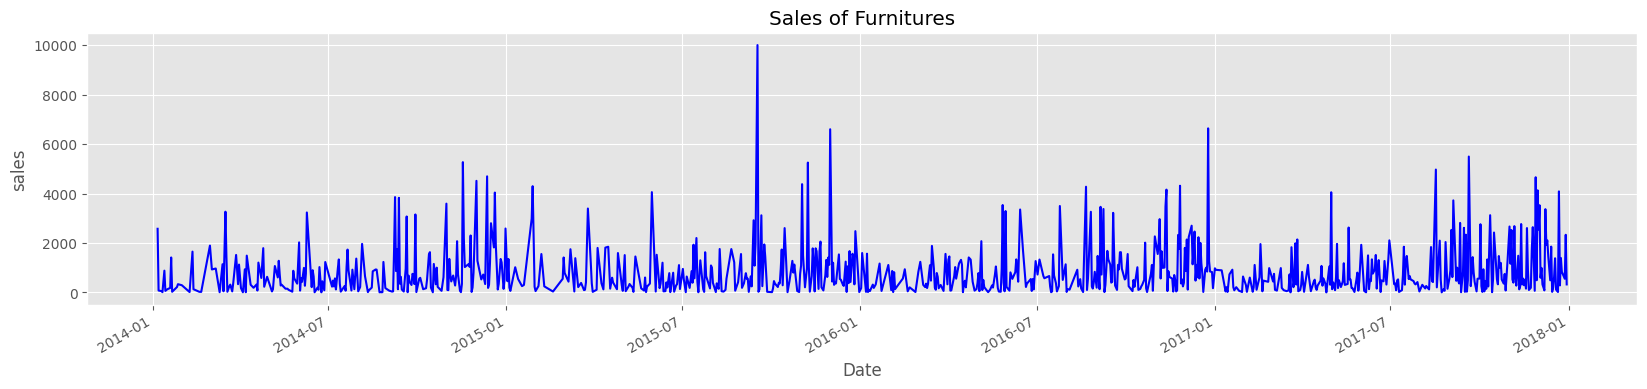

In [9]:
ax= furniture['sales'].plot(color='blue',figsize=(20,4))
ax.set_xlabel("Date")
ax.set_ylabel('sales')
ax.set_title("Sales of Furnitures")
plt.show()

In [11]:
# Using averages daily sales value - set start of the month as index
df = furniture['sales'].resample('MS').mean()
#df= avg_furniture_sales
#avg_technology_sales = technology_sales['sales'].resample('MS').mean()
#avg_office_sales = office_sales['sales'].resample('MS').mean()

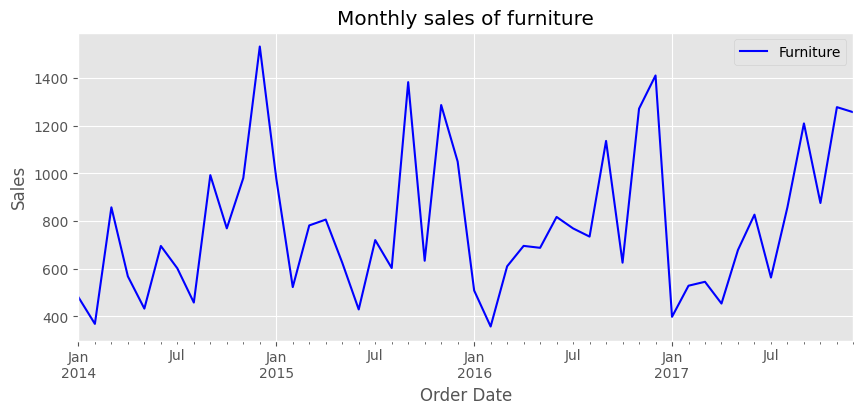

In [12]:
df.plot(figsize=(10, 4),color='blue',label = 'Furniture')

#avg_technology_sales.plot(figsize=(10, 4),color='red',label = 'Technology')

#avg_office_sales.plot(figsize=(10, 4),color='green',label = 'Office Supplies')
plt.xlabel("Order Date")
plt.ylabel('Sales')
plt.title("Monthly sales of furniture")
plt.legend()
plt.show()

## Measure of prediction accuracy

In [13]:
def performance(y_true, y_pred):
    mse = ((y_pred - y_true) ** 2).mean()
    mape= np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    performance_data= {'MSE':round(mse, 2),
                      'RMSE':round(np.sqrt(mse), 2),
                       'MAPE':round(mape, 2)
                      }
    return performance_data

def performance2(y_true, y_pred):
    #y_true, y_pred = np.array(y_true), np.array(y_pred)
    mse = ((y_pred - y_true) ** 2).mean()
    mape= np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return( print(' The MSE of forecasts is {}'.format(round(mse, 2))+
                  '\n The RMSE of forecasts is {}'.format(round(np.sqrt(mse), 2))+
                  '\n The MAPE of forecasts is {}'.format(round(mape, 2))))

## LSTM

In [14]:
train, test = np.array(df[:-12]), np.array(df[-12:])
train= train.reshape(-1,1)
test= test.reshape(-1,1)

In [15]:
#Scale train and test data to [-1, 1]
scaler = MinMaxScaler()
scaler.fit(train)
train = scaler.transform(train)
test = scaler.transform(test)

In [16]:
n_input = 12
# univariate
n_features = 1
#TimeseriesGenerator automatically transform a univariate time series dataset into a supervised learning problem.
generator = TimeseriesGenerator(train, train, length=n_input, batch_size=10)

### Vanilla LSTM

In [17]:
######
#set the counter to repeat
n=3
store= np.zeros((12,n))
for i in range(n):
    model_vanilla = Sequential()
    model_vanilla.add(LSTM(50, activation='relu', input_shape=(12, 1)))
    #Add layer
    model_vanilla.add(Dense(100, activation='relu'))
    model_vanilla.add(Dense(100, activation='relu'))
    #Output
    model_vanilla.add(Dense(1))
    model_vanilla.compile(optimizer='adam', loss='mse')
    # 22
    model_vanilla.fit_generator(generator,epochs=200)

    pred_list = []

    batch = train[-n_input:].reshape((1, n_input, n_features))

    for j in range(n_input):
        pred_list.append(model_vanilla.predict(batch)[0])
        batch = np.append(batch[:,1:,:],[[pred_list[j]]],axis=1)

    df_predict_vanilla = pd.DataFrame(scaler.inverse_transform(pred_list),
                              index=df[-n_input:].index, columns=['Prediction'])


    store[:,i]=df_predict_vanilla['Prediction']
print(store)

Epoch 1/200
3/3 [==============================] - 2s 10ms/step - loss: 0.1861
Epoch 2/200
3/3 [==============================] - 0s 12ms/step - loss: 0.1469
Epoch 3/200
3/3 [==============================] - 0s 11ms/step - loss: 0.1133
Epoch 4/200
3/3 [==============================] - 0s 14ms/step - loss: 0.0874
Epoch 5/200
3/3 [==============================] - 0s 19ms/step - loss: 0.0690
Epoch 6/200
3/3 [==============================] - 0s 22ms/step - loss: 0.0676
Epoch 7/200
3/3 [==============================] - 0s 11ms/step - loss: 0.0746
Epoch 8/200
3/3 [==============================] - 0s 11ms/step - loss: 0.0816
Epoch 9/200
3/3 [==============================] - 0s 11ms/step - loss: 0.0830
Epoch 10/200
3/3 [==============================] - 0s 10ms/step - loss: 0.0790
Epoch 11/200
3/3 [==============================] - 0s 11ms/step - loss: 0.0688
Epoch 12/200
3/3 [==============================] - 0s 12ms/step - loss: 0.0669
Epoch 13/200
3/3 [==============================]

In [18]:
final_vanilla= np.zeros((store.shape[0],1))

#final_vanilla= np.zeros((store.shape[0],1))
for i in range(store.shape[0]):

    final_vanilla[i]=np.mean(store[i,:])
final_vanilla=final_vanilla.reshape((12,))

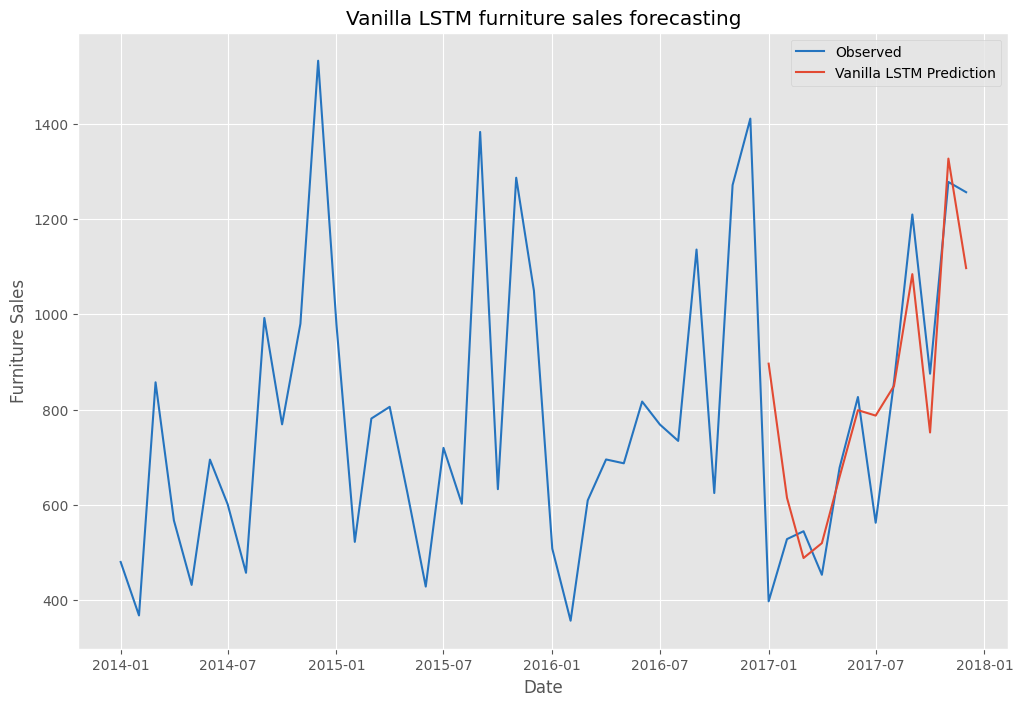

In [19]:
# report performance
rcParams['figure.figsize'] = 12, 8
# line plot of observed vs predicted
plt.plot(df.index,df,label="Observed",color='#2574BF')
plt.plot(df[36:].index,final_vanilla,label="Vanilla LSTM Prediction")
plt.title('Vanilla LSTM furniture sales forecasting')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend()
plt.show()

In [20]:
vanilla_lstm= performance(df[-12:],final_vanilla)
vanilla_lstm

{'MSE': 31201.62, 'RMSE': 176.64, 'MAPE': 21.24}

### Stacked LSTM

In [21]:
######
n=3
store2= np.zeros((12,n))
for i in range(n):
    model_stacked = Sequential()
    #In stacked LSTM, we should output a sequence rather than a single value for each input -> return_sequences=True
    model_stacked.add(LSTM(50, activation='relu', return_sequences = True, input_shape=(12, 1)))
    model_stacked.add(LSTM(50, activation='relu'))
    model_stacked.add(Dense(100, activation='relu'))
    model_stacked.add(Dense(50, activation='relu'))
    model_stacked.add(Dense(1))
    model_stacked.compile(optimizer='adam', loss='mse')
    model_stacked.fit_generator(generator,epochs=200)

    pred_list_s = []

    batch = train[-n_input:].reshape((1, n_input, n_features))

    for j in range(n_input):
        pred_list_s.append(model_stacked.predict(batch)[0])
        batch = np.append(batch[:,1:,:],[[pred_list_s[j]]],axis=1)

    df_predict_stacked = pd.DataFrame(scaler.inverse_transform(pred_list_s),
                              index=df[-n_input:].index, columns=['Prediction'])


    store2[:,i]=df_predict_stacked['Prediction']
print(store2)

Epoch 1/200
3/3 [==============================] - 3s 18ms/step - loss: 0.2050
Epoch 2/200
3/3 [==============================] - 0s 18ms/step - loss: 0.1889
Epoch 3/200
3/3 [==============================] - 0s 20ms/step - loss: 0.1718
Epoch 4/200
3/3 [==============================] - 0s 19ms/step - loss: 0.1505
Epoch 5/200
3/3 [==============================] - 0s 23ms/step - loss: 0.1263
Epoch 6/200
3/3 [==============================] - 0s 19ms/step - loss: 0.0985
Epoch 7/200
3/3 [==============================] - 0s 16ms/step - loss: 0.0747
Epoch 8/200
3/3 [==============================] - 0s 17ms/step - loss: 0.0591
Epoch 9/200
3/3 [==============================] - 0s 20ms/step - loss: 0.0825
Epoch 10/200
3/3 [==============================] - 0s 19ms/step - loss: 0.0932
Epoch 11/200
3/3 [==============================] - 0s 18ms/step - loss: 0.0804
Epoch 12/200
3/3 [==============================] - 0s 21ms/step - loss: 0.0706
Epoch 13/200
3/3 [==============================]

In [22]:
final_stacked2= np.zeros((store2.shape[0],1))
for i in range(store2.shape[0]):

    final_stacked2[i]=np.mean(store2[i,:])
final_stacked2=final_stacked2.reshape((12,))

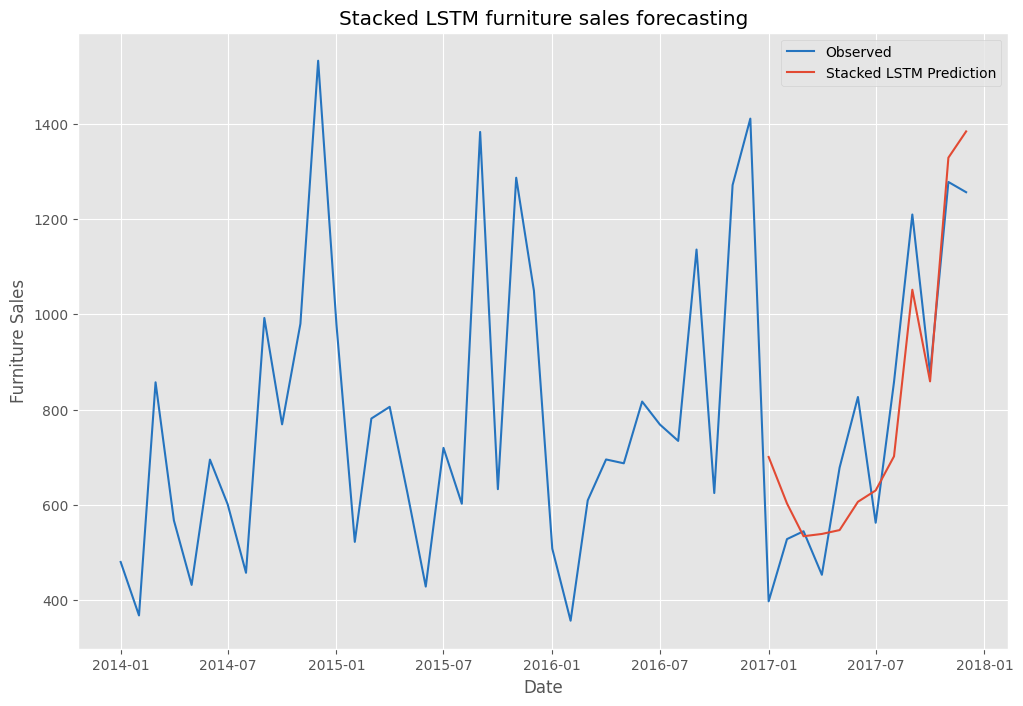

In [23]:
# report performance
rcParams['figure.figsize'] = 12, 8
# line plot of observed vs predicted
plt.plot(df.index,df,label="Observed",color='#2574BF')
plt.plot(df[36:].index,final_stacked2,label="Stacked LSTM Prediction")
plt.title('Stacked LSTM furniture sales forecasting')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend()
plt.show()

In [24]:
stacked_lstm= performance(df[-12:],final_stacked2)
stacked_lstm

{'MSE': 20288.07, 'RMSE': 142.44, 'MAPE': 18.04}

### Bidirectional LSTM

In [25]:
# define model
warnings.filterwarnings("ignore")
model_bi = Sequential()
model_bi.add(Bidirectional(LSTM(50, activation='relu'), input_shape=(12, 1)))
model_bi.add(Dense(1))
model_bi.compile(optimizer='adam', loss='mse')

In [26]:
model_bi.fit_generator(generator,epochs=200)

Epoch 1/200
3/3 [==============================] - 2s 9ms/step - loss: 0.2465
Epoch 2/200
3/3 [==============================] - 0s 9ms/step - loss: 0.2125
Epoch 3/200
3/3 [==============================] - 0s 9ms/step - loss: 0.1820
Epoch 4/200
3/3 [==============================] - 0s 9ms/step - loss: 0.1536
Epoch 5/200
3/3 [==============================] - 0s 10ms/step - loss: 0.1292
Epoch 6/200
3/3 [==============================] - 0s 10ms/step - loss: 0.1071
Epoch 7/200
3/3 [==============================] - 0s 11ms/step - loss: 0.0899
Epoch 8/200
3/3 [==============================] - 0s 9ms/step - loss: 0.0758
Epoch 9/200
3/3 [==============================] - 0s 9ms/step - loss: 0.0637
Epoch 10/200
3/3 [==============================] - 0s 10ms/step - loss: 0.0697
Epoch 11/200
3/3 [==============================] - 0s 10ms/step - loss: 0.0722
Epoch 12/200
3/3 [==============================] - 0s 9ms/step - loss: 0.0812
Epoch 13/200
3/3 [==============================] - 0s 9

In [27]:
pred_list_b = []

batch = train[-n_input:].reshape((1, n_input, n_features))

for i in range(n_input):
    pred_list_b.append(model_bi.predict(batch)[0])
    batch = np.append(batch[:,1:,:],[[pred_list_b[i]]],axis=1)

df_predict_bi = pd.DataFrame(scaler.inverse_transform(pred_list_b),
                          index=df[-n_input:].index, columns=['Prediction'])

1/1 [==============================] - 0s 37ms/step


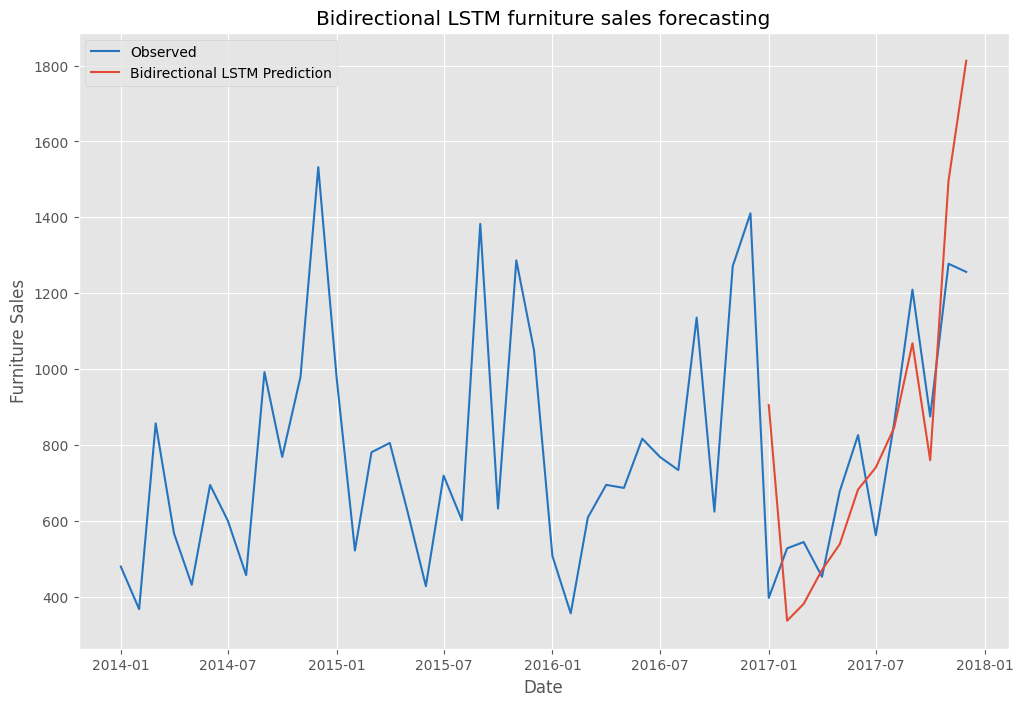

In [28]:
# report performance
rcParams['figure.figsize'] = 12, 8
# line plot of observed vs predicted
plt.plot(df.index,df,label="Observed",color='#2574BF')
plt.plot(df[36:].index,df_predict_bi,label="Bidirectional LSTM Prediction")
plt.title('Bidirectional LSTM furniture sales forecasting')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend()
plt.show()

In [29]:
bi_lstm= performance(df[-12:],df_predict_bi['Prediction'] )
bi_lstm

{'MSE': 65282.46, 'RMSE': 255.5, 'MAPE': 29.58}

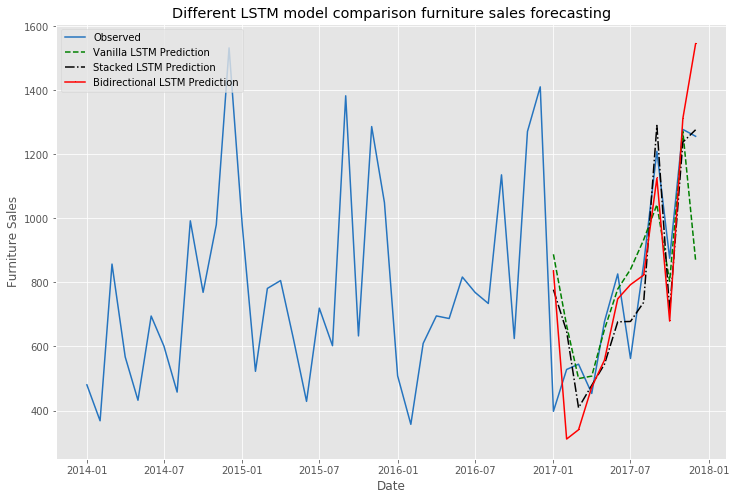

In [ ]:
# report performance
rcParams['figure.figsize'] = 12, 8
# line plot of observed vs predicted
plt.plot(df.index,df,label="Observed",color='#2574BF')
#Vanilla LSTM
plt.plot(df[36:].index,df_predict_vanilla,label="Vanilla LSTM Prediction",linestyle= "--", color='g')
#STacked LSTM
plt.plot(df[36:].index,df_predict_stacked,label="Stacked LSTM Prediction",linestyle= "-.", color="black")
#Bidirectional LSTM
plt.plot(df[36:].index,df_predict_bi,label="Bidirectional LSTM Prediction",marker=',',color='r')
plt.title('Different LSTM model comparison furniture sales forecasting')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend(loc='upper left')
plt.show()

### LSTM model 1

In [30]:
X = df.values

In [31]:
# Transform Time Series to Supervised Learning
def timeseries_to_supervised(data, lag=1):
    df = DataFrame(data)
    columns = [df.shift(i) for i in range(1, lag+1)]
    columns.append(df)
    df = concat(columns, axis=1)
    df.fillna(0, inplace=True)
    return df
# Make a differenced series to make time-series stationary
def difference(dataset, interval=1):
    diff = list()
    for i in range(interval, len(dataset)):
        value = dataset[i] - dataset[i - interval]
        diff.append(value)
    return Series(diff)

# invert differenced value
def inverse_difference(history, yhat, interval=1):
    return yhat + history[-interval]

In [32]:
# Transform Time Series to Stationary
raw_values = df.values
diff_values = difference(raw_values, 1)

In [33]:
# Transform Time Series to Supervised Learning
supervised = timeseries_to_supervised(diff_values, 1)
supervised_values = supervised.values

In [34]:
train_size = int(len(df) * 0.75)
trainset, testset= supervised_values[0:-12], supervised_values[-12:]

In [35]:
# Scale train and test data to [-1, 1]
def scale(train, test):
    # fit scaler
    scaler = MinMaxScaler(feature_range=(-1, 1))
    scaler = scaler.fit(train)
    # transform train
    train = train.reshape(train.shape[0], train.shape[1])
    train_scaled = scaler.transform(train)
    # transform test
    test = test.reshape(test.shape[0], test.shape[1])
    test_scaled = scaler.transform(test)
    return scaler, train_scaled, test_scaled

In [36]:
#  Invert the scale on forecasts to the original scale
def invert_scale(scaler, X, value):
    new_row = [x for x in X] + [value]
    array = np.array(new_row)
    array = array.reshape(1, len(array))
    inverted = scaler.inverse_transform(array)
    return inverted[0, -1]

In [37]:
# transform the scale of the data
scaler, train_scaled, test_scaled = scale(trainset, testset)

In [38]:
# fit an LSTM network to train the data
def fit_lstm(train, batch_size, nb_epoch, neurons):
    X, y = train[:, 0:-1], train[:, -1]
    X = X.reshape(X.shape[0], 1, X.shape[1])
    model = Sequential()
    model.add(LSTM(neurons, batch_input_shape=(batch_size, X.shape[1], X.shape[2]), stateful=True))
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam')
    for i in range(nb_epoch):
        #epoch can be changed to 1
        model.fit(X, y, epochs=5, batch_size=batch_size, verbose=1, shuffle=False)
        model.reset_states()
    return model

In [39]:
# fit the model
lstm_model = fit_lstm(train_scaled, 1, 100, 4)
# forecast the entire training dataset to build up state for forecasting
train_reshaped = train_scaled[:, 0].reshape(len(train_scaled), 1, 1)
lstm_model.predict(train_reshaped, batch_size=1)

Epoch 1/5
35/35 [==============================] - 2s 2ms/step - loss: 0.2180
Epoch 2/5
35/35 [==============================] - 0s 2ms/step - loss: 0.2157
Epoch 3/5
35/35 [==============================] - 0s 2ms/step - loss: 0.2132
Epoch 4/5
35/35 [==============================] - 0s 2ms/step - loss: 0.2108
Epoch 5/5
35/35 [==============================] - 0s 2ms/step - loss: 0.2085
Epoch 1/5
35/35 [==============================] - 0s 2ms/step - loss: 0.2057
Epoch 2/5
35/35 [==============================] - 0s 2ms/step - loss: 0.2038
Epoch 3/5
35/35 [==============================] - 0s 2ms/step - loss: 0.2015
Epoch 4/5
35/35 [==============================] - 0s 2ms/step - loss: 0.1992
Epoch 5/5
35/35 [==============================] - 0s 2ms/step - loss: 0.1969
Epoch 1/5
35/35 [==============================] - 0s 2ms/step - loss: 0.1940
Epoch 2/5
35/35 [==============================] - 0s 2ms/step - loss: 0.1924
Epoch 3/5
35/35 [==============================] - 0s 2ms/step -

array([[ 0.19811997],
       [ 0.39039013],
       [-0.3827641 ],
       [ 0.48922426],
       [ 0.39163852],
       [-0.03337212],
       [ 0.27095473],
       [ 0.40134978],
       [-0.4116939 ],
       [ 0.27911443],
       [-0.07672121],
       [-0.7464888 ],
       [ 0.09733397],
       [ 0.39586434],
       [ 0.11252278],
       [ 0.06860118],
       [ 0.29613504],
       [ 0.45405722],
       [ 0.03852097],
       [ 0.30713582],
       [-0.78583604],
       [ 0.57313895],
       [-0.45773855],
       [-0.2095922 ],
       [ 0.10094565],
       [ 0.33078408],
       [ 0.06842592],
       [-0.0215107 ],
       [ 0.08567542],
       [ 0.04017523],
       [ 0.15319695],
       [ 0.24652912],
       [-0.20831689],
       [ 0.45689625],
       [-0.4121519 ]], dtype=float32)

In [40]:
# make a one-step forecast
def forecast_lstm(model, batch_size, X):
    X = X.reshape(1, 1, len(X))
    yhat = model.predict(X, batch_size=batch_size)
    return yhat[0,0]

In [41]:
# walk-forward validation on the test data
predictions_lstm1 = list()
for i in range(len(test_scaled)):
    # make one-step forecast
    X, y = test_scaled[i, 0:-1], test_scaled[i, -1]
    yhat = forecast_lstm(lstm_model, 1, X)
    # invert scaling
    yhat = invert_scale(scaler, X, yhat)
    # invert differencing
    yhat = inverse_difference(raw_values, yhat, len(test_scaled)+1-i)
    # store forecast
    predictions_lstm1.append(yhat)
    expected = raw_values[len(train_scaled) + i ]
    print('Month=%d, Predicted=%f, Expected=%f' % (i+1, yhat, expected))

1/1 [==============================] - 0s 18ms/step
Month=1, Predicted=1034.441534, Expected=1410.719808
1/1 [==============================] - 0s 20ms/step
Month=2, Predicted=563.024556, Expected=397.602133
1/1 [==============================] - 0s 17ms/step
Month=3, Predicted=663.299244, Expected=528.179800
1/1 [==============================] - 0s 18ms/step
Month=4, Predicted=613.863157, Expected=544.672240
1/1 [==============================] - 0s 18ms/step
Month=5, Predicted=607.086064, Expected=453.297905
1/1 [==============================] - 0s 18ms/step
Month=6, Predicted=696.218633, Expected=678.302328
1/1 [==============================] - 0s 18ms/step
Month=7, Predicted=766.616324, Expected=826.460291
1/1 [==============================] - 0s 22ms/step
Month=8, Predicted=768.810259, Expected=562.524857
1/1 [==============================] - 0s 20ms/step
Month=9, Predicted=865.904852, Expected=857.881889
1/1 [==============================] - 0s 21ms/step
Month=10, Predicted

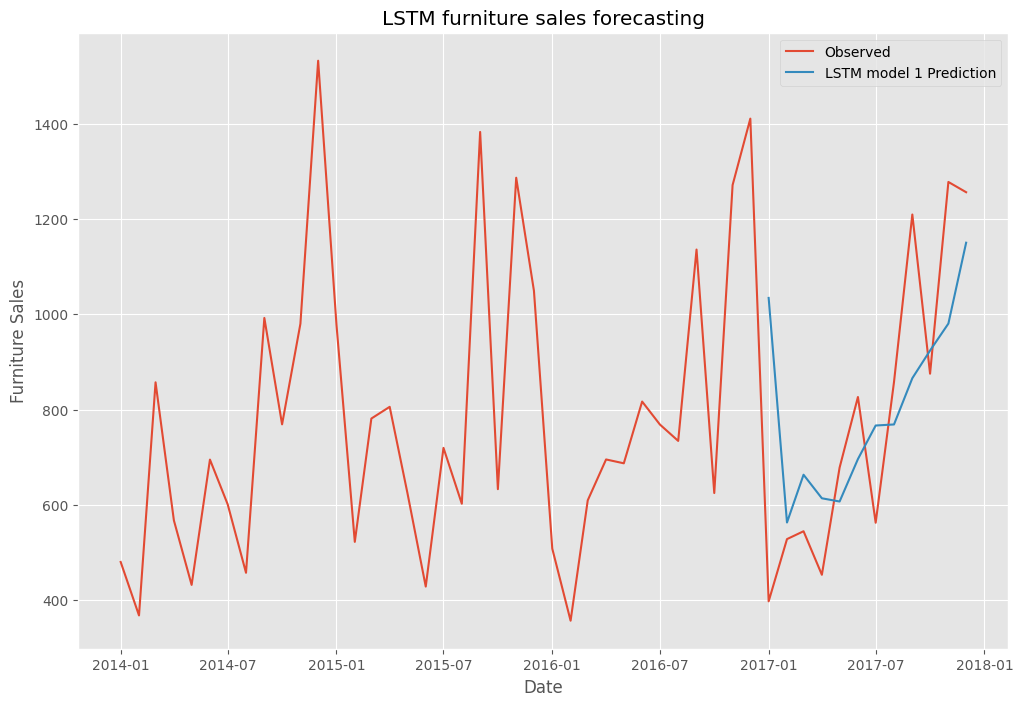

In [42]:
# report performance
rcParams['figure.figsize'] = 12, 8
# line plot of observed vs predicted
plt.plot(df.index,df,label="Observed")
plt.plot(df[36:].index,predictions_lstm1,label="LSTM model 1 Prediction")
plt.title('LSTM furniture sales forecasting')
plt.xlabel('Date')
plt.ylabel('Furniture Sales')
plt.legend()
plt.show()

In [43]:
lstm1= performance(raw_values[-12:], predictions_lstm1)
lstm1

{'MSE': 61520.98, 'RMSE': 248.03, 'MAPE': 30.21}